In [2]:
import numpy as np
import os
import sys

import wave
import copy
import math

from keras.models import Sequential, Model
from keras.layers import Dense, Activation
from keras.layers import LSTM, Input, Flatten, Concatenate, Embedding, Convolution1D,Dropout
from keras.layers import TimeDistributed
from keras.optimizers import SGD, Adam, RMSprop
from keras.layers import BatchNormalization
from sklearn.preprocessing import label_binarize
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.preprocessing import sequence

from pathlib import Path

# Define the path to the helper files
helperfiles_path = Path('C:/Users/91984/Desktop/project work')

# Import your modules
import sys
sys.path.append(str(helperfiles_path))

from features import *
from helper import *




In [3]:
code_path = os.path.dirname(os.path.realpath(os.getcwd()))
emotions_used = np.array(['ang', 'exc', 'neu', 'sad'])
data_path = code_path + "/../data/sessions/"
sessions = ['Session1', 'Session2', 'Session3', 'Session4', 'Session5']
framerate = 16000

In [4]:
import pickle

data_path = 'C:/Users/91984/Desktop/project work/data_collected_full.pickle'

with open(data_path, 'rb') as handle:
    data2 = pickle.load(handle)


In [5]:
text = []

for ses_mod in data2:
    text.append(ses_mod['transcription'])

In [6]:
MAX_SEQUENCE_LENGTH = 500

tokenizer = Tokenizer()
tokenizer.fit_on_texts(text)

token_tr_X = tokenizer.texts_to_sequences(text)
x_train_text = []

x_train_text = sequence.pad_sequences(token_tr_X, maxlen=MAX_SEQUENCE_LENGTH)

In [7]:
import codecs
EMBEDDING_DIM = 300

word_index = tokenizer.word_index
print('Found %s unique tokens' % len(word_index))

file_loc = 'C:/Users/91984/Desktop/project work/glove.42B.300d.txt'

print (file_loc)

gembeddings_index = {}
with codecs.open(file_loc, encoding='utf-8') as f:
    for line in f:
        values = line.split(' ')
        word = values[0]
        gembedding = np.asarray(values[1:], dtype='float32')
        gembeddings_index[word] = gembedding
#
f.close()
print('G Word embeddings:', len(gembeddings_index))

nb_words = len(word_index) +1
g_word_embedding_matrix = np.zeros((nb_words, EMBEDDING_DIM))
for word, i in word_index.items():
    gembedding_vector = gembeddings_index.get(word)
    if gembedding_vector is not None:
        g_word_embedding_matrix[i] = gembedding_vector
        
print('G Null word embeddings: %d' % np.sum(np.sum(g_word_embedding_matrix, axis=1) == 0))

Found 2736 unique tokens
C:/Users/91984/Desktop/project work/glove.42B.300d.txt
G Word embeddings: 1917494
G Null word embeddings: 90


In [8]:
from sklearn.preprocessing import label_binarize

y_train = []
for ses_mod in data2:
    y_train.append(ses_mod['emotion'])

# Check what emotions_used is
print("Emotions used:", emotions_used)

# Use label_binarize correctly
y_train = label_binarize(y_train, classes=emotions_used)

# Check the shape of Y
print("Shape of y_train:", y_train.shape)

Emotions used: ['ang' 'exc' 'neu' 'sad']
Shape of y_train: (4936, 4)


In [9]:
pip install tensorflow-addons

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: tensorflow-addons in c:\users\91984\appdata\local\programs\python\python311\lib\site-packages (0.22.0)



DEPRECATION: google-images-search 1.4.6 has a non-standard dependency specifier click>=7.0<=8.1.*. pip 24.0 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of google-images-search or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 23.3.2 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input

def create_simple_tcn_model(input_length, embedding_dim, nb_words, embedding_matrix):
    inputs = Input(shape=(input_length,))
    
    # Embedding Layer
    embedding_layer = layers.Embedding(input_dim=nb_words,
                                        output_dim=embedding_dim,
                                        weights=[embedding_matrix],
                                        trainable=True)(inputs)

    # Convolutional layers to mimic TCN behavior
    x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(embedding_layer)
    x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    
    x = layers.Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(256, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.Conv1D(256, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # Flatten and Dense Layers for Classification
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(4, activation='softmax')(x)  # Assuming 4 classes for classification

    # Create the model
    model = Model(inputs=inputs, outputs=outputs)

    # Compile the model
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    return model

# Model parameters (replace with your actual values)
input_length = MAX_SEQUENCE_LENGTH  # Define your input length
embedding_dim = EMBEDDING_DIM  # Define your embedding dimension
nb_words = 2737  # Define the number of words in the vocabulary
embedding_matrix = g_word_embedding_matrix  # Pre-trained embedding matrix

# Instantiate the simple TCN-like model
simple_tcn_model = create_simple_tcn_model(input_length, embedding_dim, nb_words, embedding_matrix)
simple_tcn_model.summary()

print("Simple TCN-like Model Built")


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 500, 300)       │       821,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 500, 64)        │        57,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 500, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 250, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 250, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 250, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 125, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 125, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 125, 256)       │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 62, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15872)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,063,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,325,040 (20.31 MB)

 Trainable params: 5,325,040 (20.31 MB)

 Non-trainable params: 0 (0.00 B)

Simple TCN-like Model Built


In [11]:
xtrain_tx = x_train_text[:3838]
xtest_tx = x_train_text[3838:]
ytrain_tx = y_train[:3838]
ytest_tx = y_train[3838:]

In [12]:
simple_tcn_model = create_simple_tcn_model(input_length, embedding_dim, nb_words, embedding_matrix)

# Define training parameters
batch_size = 32  # You can adjust this based on your hardware capabilities
epochs = 50  # Number of epochs for training

# Train the model
history = simple_tcn_model.fit(
    x_train_text, 
    y_train, 
    batch_size=batch_size, 
    epochs=epochs, 
    validation_data=(xtest_tx, ytest_tx),
    verbose=1
)

Epoch 1/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 57s 261ms/step - accuracy: 0.3331 - loss: 1.3681 - val_accuracy: 0.3707 - val_loss: 1.2583
Epoch 2/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 36s 230ms/step - accuracy: 0.4055 - loss: 1.2653 - val_accuracy: 0.5446 - val_loss: 1.1104
Epoch 3/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 28s 183ms/step - accuracy: 0.5093 - loss: 1.0962 - val_accuracy: 0.6603 - val_loss: 0.8828
Epoch 4/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 29s 190ms/step - accuracy: 0.6208 - loss: 0.9214 - val_accuracy: 0.7404 - val_loss: 0.7045
Epoch 5/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 30s 191ms/step - accuracy: 0.7259 - loss: 0.7384 - val_accuracy: 0.7842 - val_loss: 0.5640
Epoch 6/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 29s 184ms/step - accuracy: 0.7850 - loss: 0.5740 - val_accuracy: 0.8297 - val_loss: 0.4990
Epoch 7/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 29s 188ms/step - accuracy: 0.8267 - loss: 0.5049 - val_accuracy: 0.8679 - val_loss: 0.3858
Epoch 8/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 29s 189ms/step - accuracy: 0.8440 - loss: 0

In [13]:
# Evaluate the model
test_loss, test_acc = simple_tcn_model.evaluate(xtest_tx, ytest_tx)
print('Test accuracy:', test_acc)

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9255 - loss: 0.1566
Test accuracy: 0.9307832717895508


In [14]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
def plot_training_history(history):
    # Plot training & validation accuracy
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)  # 1 row, 2 columns, first plot
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')

    # Plot training & validation loss
    plt.subplot(1, 2, 2)  # 1 row, 2 columns, second plot
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()


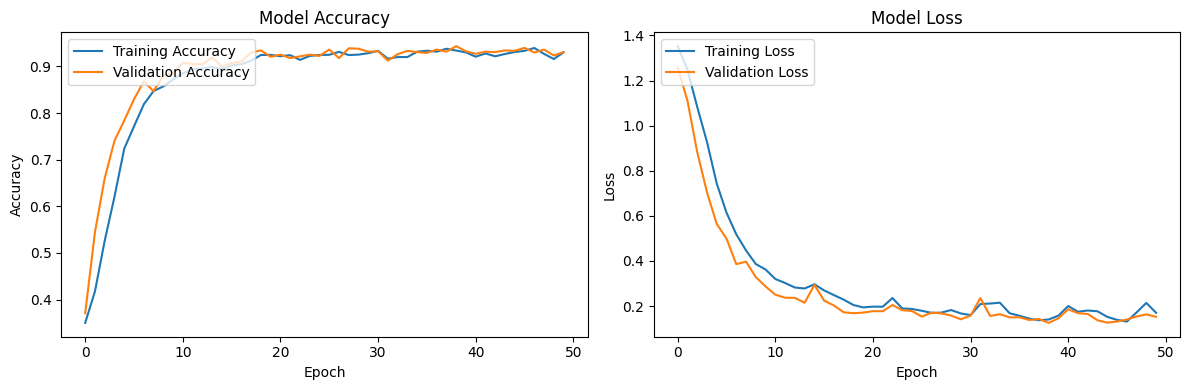

In [15]:
# Call the function to plot the training history
plot_training_history(history)

In [16]:
y_pred=simple_tcn_model.predict(xtest_tx)
y_pred_classes = y_pred.argmax(axis=1)
y_true = ytest_tx.argmax(axis=1)

35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step


In [17]:
from sklearn.metrics import classification_report

# Classification report
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.90      0.97      0.93       170
           1       0.99      0.86      0.92       299
           2       0.90      0.96      0.93       384
           3       0.95      0.95      0.95       245

    accuracy                           0.93      1098
   macro avg       0.93      0.93      0.93      1098
weighted avg       0.93      0.93      0.93      1098



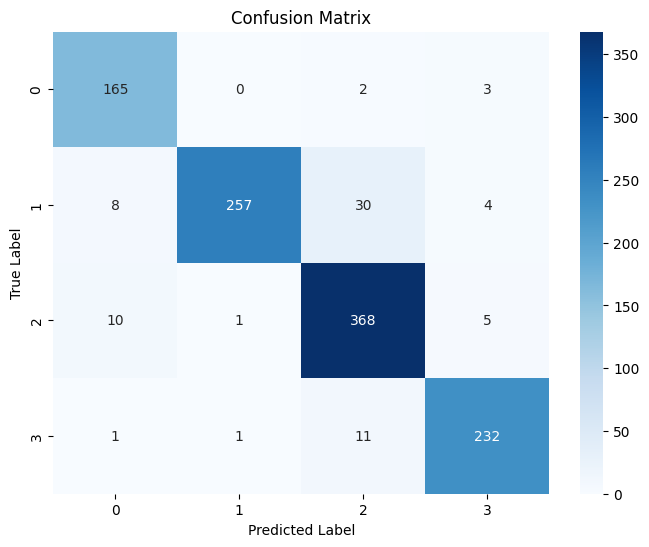

In [18]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [19]:
# Save the model to a specific location
simple_tcn_model.save('C:/Users/91984/Desktop/project_model/simple_tcn_model.h5')  


In [20]:
# Save the model to a specific location
simple_tcn_model.save('C:/Users/91984/Desktop/project_model/simple_tcn_model.keras')  


In [22]:
# Save the tokenizer for future use
import pickle
with open('C:/Users/91984/Desktop/project_model/tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)